# RPM validation methodology

## Data selection and classification

The analysis includes CSV recordings located in the repository `data` directory. Recordings are assigned to the `healthy`, `misalignment`, `rear_ball`, or `front_ball` condition according to the condition label encoded in the filename. The nominal rotational speed is extracted from the filename field preceding the `rpm` suffix. Files containing `_SF_` are excluded from the validation set because they represent a separate acquisition category. Files that do not match the specified condition and speed naming pattern are retained outside the grouped analysis.

## Rotational-speed estimation

For each recording, the timestamp (`t_us`) and pulse-generator signal (`pg_rpm`) are read in blocks of 500,000 rows. Block-wise ingestion limits memory consumption without temporal subsampling: every row in the recording is examined. The final pulse state of each block is propagated to the next block so that rising edges occurring at block boundaries are detected without discontinuity.

A pulse event is defined as a transition of `pg_rpm` from 0 to 1. The sensor produces six rising edges per mechanical revolution. If $t_i$ denotes the timestamp of the $i$-th rising edge in microseconds, the duration of one mechanical revolution is calculated from pairs of edges separated by six pulse events:

$$
\Delta t_i = t_{i+6}-t_i.
$$

The corresponding revolution-level rotational speed is

$$
n_i = \frac{60\times10^6}{\Delta t_i}\;\mathrm{min}^{-1}.
$$

Adjacent estimates are formed with a one-edge offset; therefore, all available six-edge intervals contribute to the analysis. Direct use of recorded timestamps avoids estimating rotational speed from the nominal sampling frequency and preserves the timing information available in each acquisition.

## Recording-level metrics

The actual rotational speed of a recording is defined as the arithmetic mean of all valid revolution-level estimates, $\overline{n}$. Rotational variability is described by the standard deviation $\sigma_n$, minimum $n_{\min}$, and maximum $n_{\max}$. The relative range is calculated as

$$
R_n = \frac{n_{\max}-n_{\min}}{\overline{n}}\times100\%.
$$

The number of detected rising edges is reported as a data-availability measure. A recording is marked as invalid when the pulse sequence is absent, contains no valid positive revolution period, or provides no more than six rising edges.

## Nominal-speed validation

Agreement with the nominal speed $n_0$ is evaluated using the absolute mean-speed deviation

$$
d_n = \left|\overline{n}-n_0\right|.
$$

The admissible deviation is defined as

$$
T_n = \max\left(25\;\mathrm{min}^{-1},\;0.05n_0\right).
$$

The combined absolute and relative criterion prevents the admissible interval from becoming disproportionately narrow at low rotational speeds while maintaining a speed-proportional tolerance at higher operating points. A recording receives an `OK` status when $d_n\leq T_n$; otherwise, or when rotational speed cannot be calculated, it is marked with a red `X`.

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import HTML, display

PULSES_PER_REV = 6
CHUNK_SIZE = 500_000
RPM_TOLERANCE_PERCENT = 5.0
RPM_TOLERANCE_MIN = 25.0
GROUPS = ("healthy", "misalignment", "rear_ball", "front_ball")

data_candidates = (Path.cwd() / "data", Path.cwd().parent / "data")
DATA_DIR = next((path.resolve() for path in data_candidates if path.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find the repository data directory.")

name_pattern = re.compile(
    r"^analize_(?P<group>healthy|misalignment|rear_ball|front_ball).*?_(?P<target_rpm>\d+)rpm_"
)

def calculate_actual_rpm(csv_path):
    """Calculate revolution-averaged RPM from six PG rising edges."""
    pulse_time_chunks = []
    previous_pg = None

    for chunk in pd.read_csv(
        csv_path,
        usecols=["t_us", "pg_rpm"],
        chunksize=CHUNK_SIZE,
    ):
        times = pd.to_numeric(chunk["t_us"], errors="coerce").to_numpy(dtype=float)
        pg = pd.to_numeric(chunk["pg_rpm"], errors="coerce").to_numpy(dtype=float)
        rising = np.zeros(len(chunk), dtype=bool)

        if len(chunk):
            if previous_pg is not None:
                rising[0] = previous_pg == 0 and pg[0] == 1
            rising[1:] = (pg[:-1] == 0) & (pg[1:] == 1)
            valid_edges = rising & np.isfinite(times)
            pulse_time_chunks.append(times[valid_edges])
            finite_pg = pg[np.isfinite(pg)]
            if finite_pg.size:
                previous_pg = finite_pg[-1]

    if not pulse_time_chunks:
        raise ValueError("No PG data found")

    pulse_times_us = np.concatenate(pulse_time_chunks)
    if pulse_times_us.size <= PULSES_PER_REV:
        raise ValueError("Not enough PG rising edges")

    revolution_us = (
        pulse_times_us[PULSES_PER_REV:] - pulse_times_us[:-PULSES_PER_REV]
    )
    rpm_values = 60_000_000.0 / revolution_us
    rpm_values = rpm_values[np.isfinite(rpm_values) & (rpm_values > 0)]
    if not rpm_values.size:
        raise ValueError("No valid revolution periods")

    return {
        "actual_rpm": rpm_values.mean(),
        "rpm_std": rpm_values.std(),
        "rpm_min": rpm_values.min(),
        "rpm_max": rpm_values.max(),
        "pulses": pulse_times_us.size,
    }

print(f"Data directory: {DATA_DIR}")
print("RPM calculation functions are ready.")

Data directory: C:\Asmeninis\OpenBLDCData\data
RPM calculation functions are ready.


In [23]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
matched_files = []
for csv_path in csv_files:
    if "_SF_" in csv_path.name:
        continue
    match = name_pattern.match(csv_path.name)
    if match:
        matched_files.append((csv_path, match))

print(
    f"Found {len(csv_files)} CSV files: {len(matched_files)} grouped files and "
    f"{len(csv_files) - len(matched_files)} ungrouped files."
)

rows = []
for index, (csv_path, match) in enumerate(matched_files, start=1):
    group = match.group("group")
    target_rpm = float(match.group("target_rpm"))
    tolerance_rpm = max(RPM_TOLERANCE_MIN, target_rpm * RPM_TOLERANCE_PERCENT / 100)

    row = {
        "group": group,
        "file": csv_path.name,
        "target_rpm": target_rpm,
        "tolerance_rpm": tolerance_rpm,
    }

    try:
        rpm_stats = calculate_actual_rpm(csv_path)
        difference_rpm = rpm_stats["actual_rpm"] - target_rpm
        matches = abs(difference_rpm) <= tolerance_rpm
        row.update(
            **rpm_stats,
            difference_rpm=difference_rpm,
            matches=matches,
            status="OK" if matches else "X",
            error="",
        )
    except Exception as exc:
        row.update(
            actual_rpm=np.nan,
            rpm_std=np.nan,
            rpm_min=np.nan,
            rpm_max=np.nan,
            pulses=0,
            difference_rpm=np.nan,
            matches=False,
            status="X",
            error=str(exc),
        )

    rows.append(row)
    print(f"\rProcessed {index}/{len(matched_files)} files", end="")

print()
results = pd.DataFrame(rows)
results["group"] = pd.Categorical(results["group"], categories=GROUPS, ordered=True)
results["rpm_range_percent"] = (
    100 * (results["rpm_max"] - results["rpm_min"]) / results["actual_rpm"]
)
results = results.sort_values(["group", "target_rpm", "file"]).reset_index(drop=True)

summary = (
    results.groupby("group", observed=True)
    .agg(files=("file", "size"), matching=("matches", "sum"))
    .reset_index()
)
summary["with_red_x"] = summary["files"] - summary["matching"]

display(HTML("<h2>Validation summary</h2>"))
display(summary.style.hide(axis="index"))

table_columns = [
    "file",
    "target_rpm",
    "actual_rpm",
    "difference_rpm",
    "tolerance_rpm",
    "rpm_std",
    "rpm_min",
    "rpm_max",
    "rpm_range_percent",
    "pulses",
    "status",
    "error",
]

def status_style(value):
    if value == "X":
        return "color: #c62828; font-weight: 800; font-size: 1.15em"
    return "color: #1b5e20; font-weight: 700"

for group in GROUPS:
    group_results = results.loc[results["group"] == group, table_columns]
    display(HTML(f"<h2>{group} ({len(group_results)} files)</h2>"))
    styled = (
        group_results.style
        .hide(axis="index")
        .format(
            {
                "target_rpm": "{:.0f}",
                "actual_rpm": "{:.1f}",
                "difference_rpm": "{:+.1f}",
                "tolerance_rpm": "{:.1f}",
                "rpm_std": "{:.1f}",
                "rpm_min": "{:.1f}",
                "rpm_max": "{:.1f}",
                "rpm_range_percent": "{:.2f}%",
                "pulses": "{:.0f}",
            },
            na_rep="-",
        )
        .map(status_style, subset=["status"])
    )
    display(styled)

Found 180 CSV files: 178 grouped files and 2 ungrouped files.
Processed 178/178 files


group,files,matching,with_red_x
healthy,71,70,1
misalignment,64,64,0
rear_ball,21,21,0
front_ball,22,21,1


file,target_rpm,actual_rpm,difference_rpm,tolerance_rpm,rpm_std,rpm_min,rpm_max,rpm_range_percent,pulses,status,error
analize_healthy10_500rpm_128mA_bat.csv,500,504.7,+4.7,25.0,1.5,499.9,508.7,1.74%,14240,OK,
analize_healthy10_500rpm_19mA_bat.csv,500,515.4,+15.4,25.0,2.2,512.5,517.5,0.97%,13570,OK,
analize_healthy10_500rpm_38mA_bat.csv,500,512.3,+12.3,25.0,1.6,508.2,517.4,1.79%,13539,OK,
analize_healthy10_500rpm_64mA_bat.csv,500,503.9,+3.9,25.0,1.3,499.8,508.6,1.74%,14238,OK,
analize_healthy10_500rpm_96mA_bat.csv,500,505.6,+5.6,25.0,2.0,503.9,508.7,0.95%,13313,OK,
analize_healthy10_500rpm_96mA_mait.csv,500,497.6,-2.4,25.0,2.0,495.6,500.2,0.93%,16673,OK,
analize_healthy10_ENV_500rpm_96mA_bat.csv,500,512.0,+12.0,25.0,1.7,508.2,517.2,1.75%,22291,OK,
analize_healthy20_500rpm_128mA_mait.csv,500,504.3,+4.3,25.0,0.8,500.0,508.5,1.69%,14040,OK,
analize_healthy20_500rpm_19mA_mait.csv,500,512.6,+12.6,25.0,1.0,508.4,517.2,1.73%,13442,OK,
analize_healthy20_500rpm_38mA_mait.csv,500,511.2,+11.2,25.0,2.1,508.3,512.9,0.90%,13472,OK,


file,target_rpm,actual_rpm,difference_rpm,tolerance_rpm,rpm_std,rpm_min,rpm_max,rpm_range_percent,pulses,status,error
analize_misalignment10_500rpm_128mA_mait.csv,500,505.8,+5.8,25.0,2.1,504.1,508.6,0.89%,4038,OK,
analize_misalignment10_500rpm_19mA_mait.csv,500,500.1,+0.1,25.0,0.8,495.8,504.3,1.70%,3943,OK,
analize_misalignment10_500rpm_38mA_mait.csv,500,508.2,+8.2,25.0,1.1,504.2,508.6,0.87%,4008,OK,
analize_misalignment10_500rpm_64mA_mait.csv,500,510.8,+10.8,25.0,2.2,508.4,512.9,0.89%,4139,OK,
analize_misalignment10_500rpm_96mA_bat.csv,500,513.3,+13.3,25.0,1.5,508.5,517.4,1.74%,13465,OK,
analize_misalignment10_500rpm_96mA_mait.csv,500,509.2,+9.2,25.0,1.6,508.4,512.9,0.89%,4020,OK,
analize_misalignment10_ENV_500rpm_128mA_mait.csv,500,505.9,+5.9,25.0,2.1,504.1,508.6,0.89%,3788,OK,
analize_misalignment20_500rpm_128mA_mait.csv,500,506.2,+6.2,25.0,2.1,504.1,508.6,0.88%,3993,OK,
analize_misalignment20_500rpm_19mA_mait.csv,500,509.3,+9.3,25.0,1.7,508.3,513.0,0.91%,3975,OK,
analize_misalignment20_500rpm_38mA_mait.csv,500,506.5,+6.5,25.0,2.1,504.1,508.6,0.88%,4047,OK,


file,target_rpm,actual_rpm,difference_rpm,tolerance_rpm,rpm_std,rpm_min,rpm_max,rpm_range_percent,pulses,status,error
analize_rear_ball30_500rpm_128mA_mait.csv,500,498.0,-2.0,25.0,2.1,495.7,500.1,0.88%,4131,OK,
analize_rear_ball30_500rpm_19mA_mait.csv,500,503.7,+3.7,25.0,2.3,499.9,508.6,1.73%,5238,OK,
analize_rear_ball30_500rpm_38mA_mait.csv,500,501.1,+1.1,25.0,2.2,495.8,504.3,1.70%,4558,OK,
analize_rear_ball30_500rpm_64mA_mait.csv,500,507.5,+7.5,25.0,2.1,504.1,512.9,1.74%,4000,OK,
analize_rear_ball30_500rpm_96mA_mait.csv,500,511.3,+11.3,25.0,2.1,508.4,512.9,0.90%,5325,OK,
analize_rear_ball30_1000rpm_128mA_mait.csv,1000,1002.0,+2.0,50.0,5.4,999.6,1017.4,1.78%,7906,OK,
analize_rear_ball30_1000rpm_19mA_mait.csv,1000,1007.7,+7.7,50.0,8.4,999.5,1017.5,1.78%,8039,OK,
analize_rear_ball30_1000rpm_38mA_mait.csv,1000,1003.8,+3.8,50.0,7.0,999.6,1017.2,1.75%,7916,OK,
analize_rear_ball30_1000rpm_64mA_mait.csv,1000,1011.9,+11.9,50.0,7.7,999.5,1017.4,1.77%,8401,OK,
analize_rear_ball30_1000rpm_96mA_mait.csv,1000,1005.7,+5.7,50.0,8.0,999.6,1017.4,1.78%,8645,OK,


file,target_rpm,actual_rpm,difference_rpm,tolerance_rpm,rpm_std,rpm_min,rpm_max,rpm_range_percent,pulses,status,error
analize_front_ball30_500rpm_128mA_mait.csv,500,507.5,+7.5,25.0,5.3,491.8,517.3,5.02%,4053,OK,
analize_front_ball30_500rpm_19mA_mait.csv,500,533.0,+33.0,25.0,6.2,495.9,545.5,9.31%,4314,X,
analize_front_ball30_500rpm_38mA_mait.csv,500,519.2,+19.2,25.0,5.4,491.8,531.0,7.55%,4356,OK,
analize_front_ball30_500rpm_64mA_mait.csv,500,511.9,+11.9,25.0,6.4,483.9,526.3,8.29%,5132,OK,
analize_front_ball30_500rpm_96mA_mait.csv,500,504.3,+4.3,25.0,5.5,483.9,517.3,6.62%,4027,OK,
analize_front_ball30_1000rpm_128mA_mait.csv,1000,1018.6,+18.6,50.0,6.5,999.6,1034.7,3.45%,8132,OK,
analize_front_ball30_1000rpm_19mA_mait.csv,1000,1007.9,+7.9,50.0,8.6,983.4,1017.4,3.38%,7956,OK,
analize_front_ball30_1000rpm_38mA_mait.csv,1000,1011.5,+11.5,50.0,8.0,983.6,1017.5,3.36%,7984,OK,
analize_front_ball30_1000rpm_64mA_mait.csv,1000,1016.4,+16.4,50.0,3.6,999.7,1034.5,3.43%,8334,OK,
analize_front_ball30_1000rpm_96mA_mait.csv,1000,997.5,-2.5,50.0,5.9,983.3,1000.5,1.72%,8397,OK,


## RPM stability by operating speed

RPM stability is expressed as the relative standard deviation

$$
\mathrm{RPM\ stability\ variation} = \frac{\sigma_{\mathrm{RPM}}}{\overline{\mathrm{RPM}}}\cdot100\%.
$$

Using a relative value allows recordings at different rotational speeds to be compared on the same scale. Each point represents one CSV recording. The box spans the interquartile range across recordings, the center line is the median, and the whiskers show the remaining spread. Lower values and narrower boxes indicate more stable rotational speed.

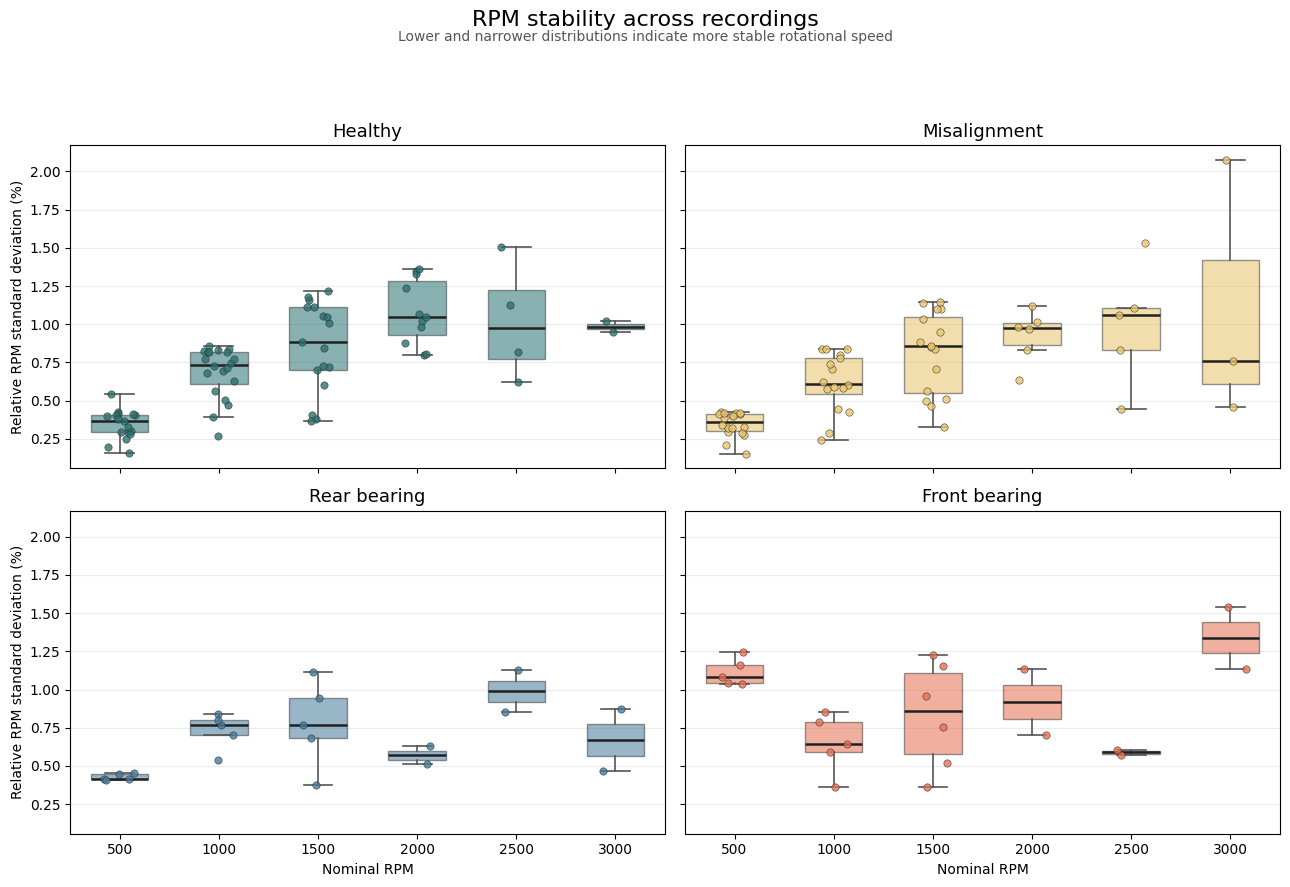

In [6]:
import matplotlib.pyplot as plt

GROUP_LABELS = {
    "healthy": "Healthy",
    "misalignment": "Misalignment",
    "rear_ball": "Rear bearing",
    "front_ball": "Front bearing",
}
GROUP_COLORS = {
    "healthy": "#287271",
    "misalignment": "#e9c46a",
    "rear_ball": "#457b9d",
    "front_ball": "#e76f51",
}

stability_data = results.dropna(subset=["actual_rpm", "rpm_std"]).copy()
stability_data["relative_rpm_std_percent"] = (
    100 * stability_data["rpm_std"] / stability_data["actual_rpm"]
)
target_speeds = sorted(stability_data["target_rpm"].unique())

figure, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
random_generator = np.random.default_rng(42)

for axis, group_name in zip(axes.flat, GROUPS):
    group_data = stability_data.loc[stability_data["group"] == group_name]
    color = GROUP_COLORS[group_name]
    box_values = [
        group_data.loc[
            group_data["target_rpm"] == target_rpm,
            "relative_rpm_std_percent",
        ].to_numpy()
        for target_rpm in target_speeds
    ]

    boxplot = axis.boxplot(
        box_values,
        positions=np.arange(len(target_speeds)),
        widths=0.58,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "#202020", "linewidth": 1.8},
        whiskerprops={"color": "#555555", "linewidth": 1.2},
        capprops={"color": "#555555", "linewidth": 1.2},
    )
    for box in boxplot["boxes"]:
        box.set(facecolor=color, edgecolor="#404040", alpha=0.55)

    for position, values in enumerate(box_values):
        if not len(values):
            continue
        jitter = random_generator.uniform(-0.16, 0.16, size=len(values))
        axis.scatter(
            position + jitter,
            values,
            s=28,
            color=color,
            edgecolor="#303030",
            linewidth=0.45,
            alpha=0.8,
            zorder=3,
        )

    axis.set_title(GROUP_LABELS[group_name], fontsize=13)
    axis.set_xticks(np.arange(len(target_speeds)))
    axis.set_xticklabels([f"{speed:.0f}" for speed in target_speeds])
    axis.grid(axis="y", alpha=0.25)
    axis.set_axisbelow(True)

for axis in axes[-1, :]:
    axis.set_xlabel("Nominal RPM")
for axis in axes[:, 0]:
    axis.set_ylabel("Relative RPM standard deviation (%)")

figure.suptitle("RPM stability across recordings", fontsize=16, y=0.98)
figure.text(
    0.5,
    0.945,
    "Lower and narrower distributions indicate more stable rotational speed",
    ha="center",
    fontsize=10,
    color="#555555",
)
figure.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()